In [ ]:
import pandas as pd # load
import seaborn as sns# count er plot, correlation er plot
import matplotlib.pyplot as plt

dataset Link- https://drive.google.com/file/d/1wDjDuqDPAJd1cQEICcu19J9vrjFAWJ1H/view

reference - https://www.kaggle.com/code/vikasukani/breast-cancer-prediction-using-machine-learning


**DATASET LOAD [ USING MOUNT]**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/CSE422 PROJECT_21101074/data1.csv")
print(data)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

In [ ]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


**Data-set Description**

In [ ]:
row,column= data.shape
print("Features:",column)
print("No of instances:", row)
print("Name of all features:")
print(data.columns)

Features: 32
No of instances: 569
Name of all features:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              566 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          568 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           567 non-null    float64
 9   concave points_mean      567 non-null    float64
 10  symmetry_mean            568 non-null    float64
 11  fractal_dimension_mean   567 non-null    float64
 12  radius_se                568 non-null    float64
 13  texture_se               568 non-null    float64
 14  perimeter_se             5

In [ ]:
print("Types of features:")
print(data.dtypes)

Types of features:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
c

**Correlation heat map **

<ipython-input-21-9cd94c22dc61>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  hm = sns.heatmap(data.iloc[:,1:15].corr())


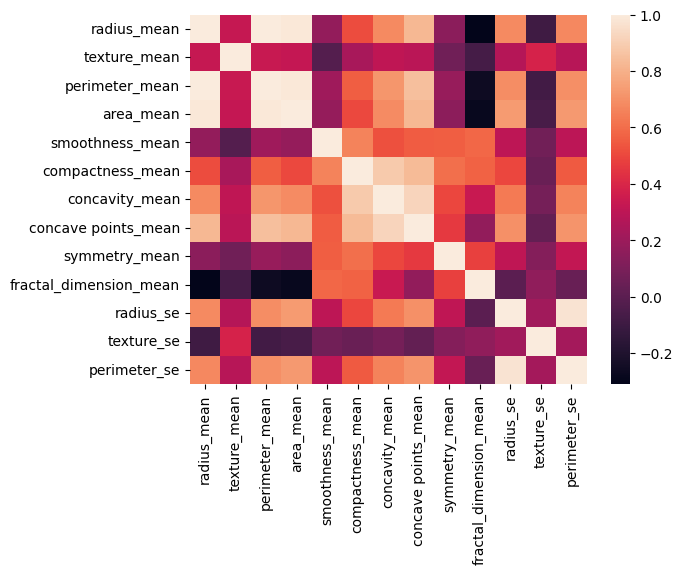

In [ ]:
hm = sns.heatmap(data.iloc[:,1:15].corr())

# displaying the plotted heatmap
plt.show(hm)

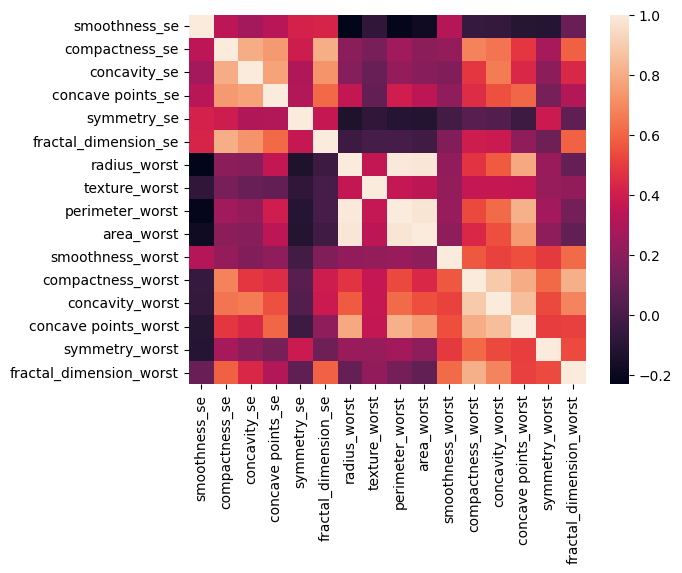

In [ ]:
hm = sns.heatmap(data.iloc[:,16:32].corr())

# displaying the plotted heatmap
plt.show()

<Axes: >

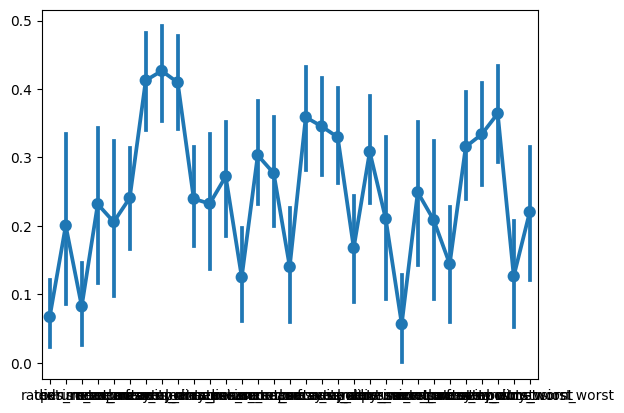

In [ ]:
sns.pointplot(data.groupby("diagnosis").corr())

In [ ]:
data.groupby("diagnosis").corr()

id  radius_mean  texture_mean  \
diagnosis                                                                
B         id                       1.000000    -0.032465      0.043933   
          radius_mean             -0.032465     1.000000     -0.037150   
          texture_mean             0.043933    -0.037150      1.000000   
          perimeter_mean          -0.036449     0.996769     -0.039923   
          area_mean               -0.026036     0.994435     -0.039055   
...                                     ...          ...           ...   
M         compactness_worst       -0.047110    -0.110616      0.104080   
          concavity_worst         -0.018537     0.073619      0.110075   
          concave points_worst     0.035155     0.389203     -0.002213   
          symmetry_worst          -0.146282    -0.259061     -0.087386   
          fractal_dimension_worst -0.096551    -0.378281      0.025960   

                                   perimeter_mean  area_mean  smoothness_mean  \
diagnosis                                                                       
B         id                            -0.036449  -0.026036        -0.027307   
          radius_mean                    0.996769   0.994435        -0.185118   
          texture_mean                  -0.039923  -0.039055        -0.233814   
          perimeter_mean                 1.000000   0.990653        -0.148729   
          area_mean                      0.990653   1.000000        -0.203128   
...                                           ...        ...              ...   
M         compactness_worst             -0.048618  -0.108104         0.482540   
          concavity_worst                0.134977   0.077150         0.520336   
          concave points_worst           0.437786   0.385717         0.509215   
          symmetry_worst                -0.231742  -0.270648         0.346567   
          fractal_dimension_worst       -0.326549  -0.366243         0.548727   

                                   compactness_mean  concavity_mean  \
diagnosis                                                             
B         id                              -0.055478       -0.012370   
          radius_mean                      0.060442        0.086757   
          texture_mean                    -0.058695       -0.023084   
          perimeter_mean                   0.135411        0.147612   
          area_mean                        0.052353        0.092317   
...                                             ...             ...   
M         compactness_worst                0.791052        0.536969   
          concavity_worst                  0.755552        0.736783   
          concave points_worst             0.740223        0.746120   
          symmetry_worst                   0.439311        0.199880   
          fractal_dimension_worst          0.628215        0.328335   

                                   concave points_mean  symmetry_mean  ...  \
diagnosis                                                              ...   
B         id                                 -0.049537       0.025388  ...   
          radius_mean                         0.411571      -0.235576  ...   
          texture_mean                       -0.142093      -0.068707  ...   
          perimeter_mean                      0.465252      -0.208957  ...   
          area_mean                           0.403159      -0.237391  ...   
...                                                ...            ...  ...   
M         compactness_worst                   0.355540       0.521549  ...   
          concavity_worst                     0.515181       0.473445  ...   
          concave points_worst                0.770398       0.476454  ...   
          symmetry_worst                      0.097345       0.710495  ...   
          fractal_dimension_worst             0.138827       0.471685  ...   

                                   radius_worst  texture_worst  \
diagnosis          

**Biasness**

In [ ]:
#checking all column has same no of rows or not
ct=data["id"].count()
check=0

for i in data.columns: # checking if all features same same no of row
  if data[i].count()!=ct:
    #print(i,data[i].count())
    pass
  else:
    check=check+1
row,column= data.shape
if check == column:
  print("all class has same no of row")
else:
  print("Because of null values Not all class has same no of row ")


Because of null values Not all class has same no of row 


{'id': 569, 'diagnosis': 569, 'radius_mean': 566, 'texture_mean': 569, 'perimeter_mean': 569, 'area_mean': 569, 'smoothness_mean': 568, 'compactness_mean': 569, 'concavity_mean': 567, 'concave points_mean': 567, 'symmetry_mean': 568, 'fractal_dimension_mean': 567, 'radius_se': 568, 'texture_se': 568, 'perimeter_se': 569, 'area_se': 568, 'smoothness_se': 568, 'compactness_se': 568, 'concavity_se': 568, 'concave points_se': 568, 'symmetry_se': 568, 'fractal_dimension_se': 568, 'radius_worst': 569, 'texture_worst': 569, 'perimeter_worst': 569, 'area_worst': 569, 'smoothness_worst': 569, 'compactness_worst': 569, 'concavity_worst': 569, 'concave points_worst': 569, 'symmetry_worst': 569, 'fractal_dimension_worst': 569}


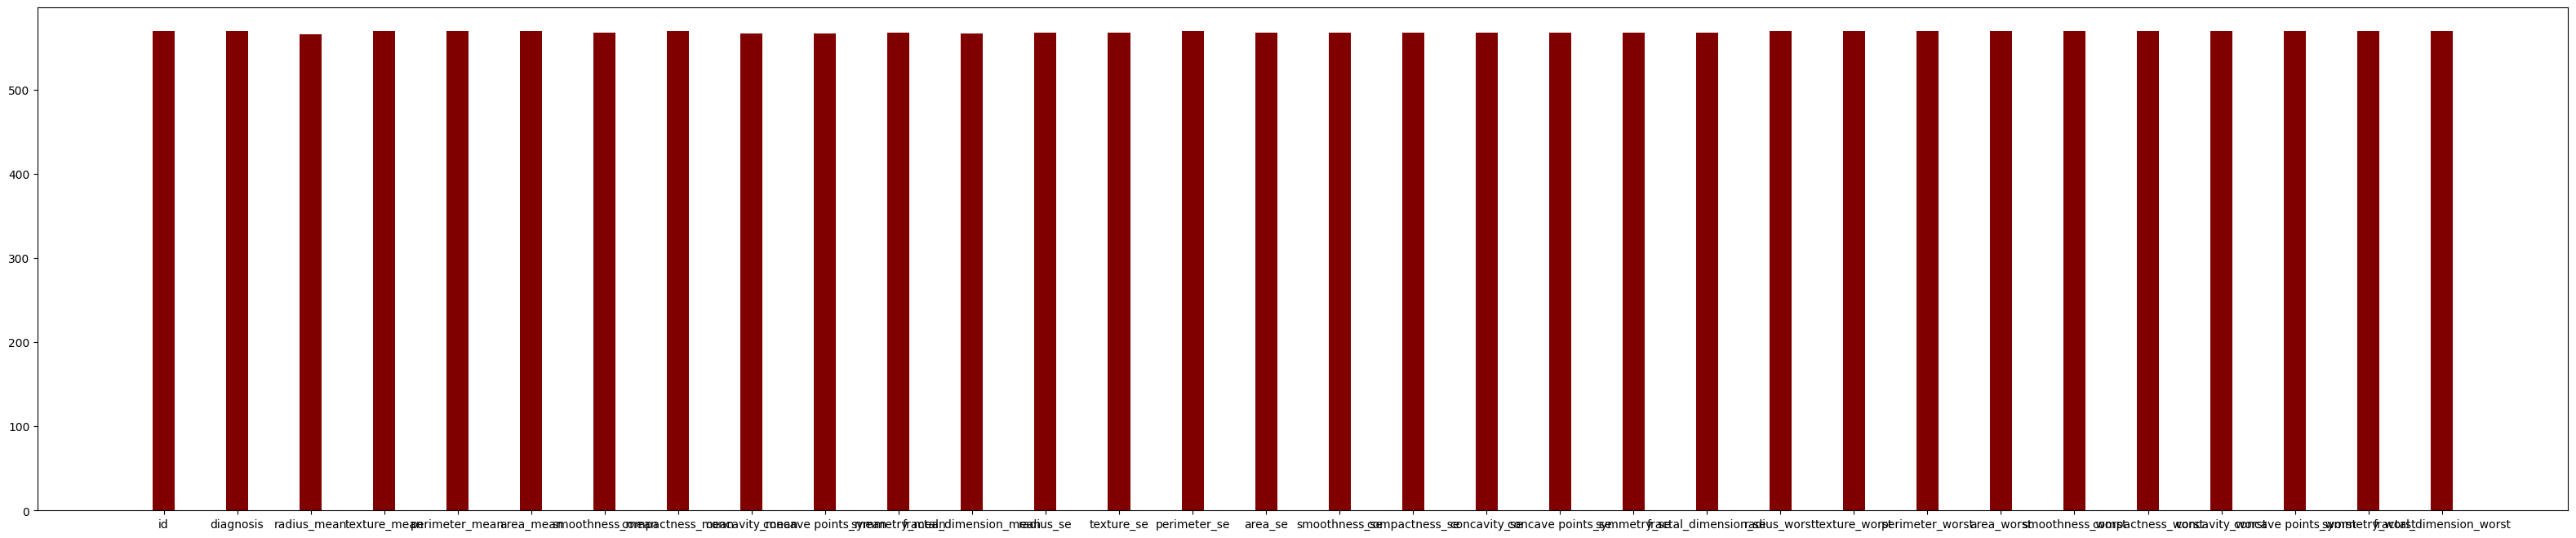

In [ ]:
#Represent using a barchart of N classes(N=number of classes you have in your dataset).
dict={}
for i in data.columns:
  dict[i]=data[i].count()
print(dict)
courses = list(dict.keys())
values = list(dict.values())

fig = plt.figure(figsize = (40, 8))

# creating the bar plot
plt.bar(courses, values, color ='maroon',
        width = 0.3)
plt.show()

**DATA PRE PROCESSING**


**1.NULL values and removing null value using Impute**

In [ ]:
# checking my dataset has null value or not

data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                3
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            1
compactness_mean           0
concavity_mean             2
concave points_mean        2
symmetry_mean              1
fractal_dimension_mean     2
radius_se                  1
texture_se                 1
perimeter_se               0
area_se                    1
smoothness_se              1
compactness_se             1
concavity_se               1
concave points_se          1
symmetry_se                1
fractal_dimension_se       1
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [ ]:
#Removing of Null value using IMPUTE
dict1={}
for i in range(len(data.isnull().sum())):
  dict1[data.columns[i]]=data.isnull().sum()[i]
print(dict1)

##impute

for key,value in dict.items():
  if value>0:
    data[key] = data[key].fillna(data[key].mode()[0])

#AFTER IMPUTE

data.isnull().sum()


{'id': 0, 'diagnosis': 0, 'radius_mean': 3, 'texture_mean': 0, 'perimeter_mean': 0, 'area_mean': 0, 'smoothness_mean': 1, 'compactness_mean': 0, 'concavity_mean': 2, 'concave points_mean': 2, 'symmetry_mean': 1, 'fractal_dimension_mean': 2, 'radius_se': 1, 'texture_se': 1, 'perimeter_se': 0, 'area_se': 1, 'smoothness_se': 1, 'compactness_se': 1, 'concavity_se': 1, 'concave points_se': 1, 'symmetry_se': 1, 'fractal_dimension_se': 1, 'radius_worst': 0, 'texture_worst': 0, 'perimeter_worst': 0, 'area_worst': 0, 'smoothness_worst': 0, 'compactness_worst': 0, 'concavity_worst': 0, 'concave points_worst': 0, 'symmetry_worst': 0, 'fractal_dimension_worst': 0}


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

**2.Categorical values and Encoding**

In [ ]:
data["diagnosis"].value_counts() # As there are only two variables in diagnosis column so we will use label encoding, if it had more than 2 then we would have used on

B    357
M    212
Name: diagnosis, dtype: int64

In [ ]:
# label encoding(convert the value of M and B into 1 and 0)
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
data["diagnosis"]=labelencoder_Y.fit_transform(data["diagnosis"])

print(data["diagnosis"])

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


**Data splitting**

In [ ]:
X= data.drop(columns="diagnosis",axis=1) ##dropping column so the axis value is 1, dropping row the axis is 0.
print(X.shape)
Y=data["diagnosis"]
print(Y)

(569, 31)
0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2) #random state is a way od splitting the data, if you give 2 and i give 2 then our data will be spiltted in the same way

In [ ]:
print(X_train.shape,X_test.shape)

(455, 31) (114, 31)


**Feature Scalling**

In [ ]:
from sklearn.preprocessing import StandardScaler #only x because y shudhu 0,1 tau scale needed in X train test
X_train=StandardScaler().fit_transform(X_train)
X_test=StandardScaler().fit_transform(X_test)

**Model Training and Accuracy**

**1.Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
dct={}
dct2={}
lr=LogisticRegression().fit(X_train,Y_train)
print("Accuracy of training data")
print(lr.score(X_train,Y_train))

print("accuracy of testing data")
after=lr.predict(X_test)
dct["Logistic Rregression"]=accuracy_score(Y_test,after) #for creating barchart taking dictionary
print(accuracy_score(Y_test,after))
dct2["Logistic Rregression"]=lr.score(X_train,Y_train)-accuracy_score(Y_test,after)
print("ERROR RATE:",lr.score(X_train,Y_train)-accuracy_score(Y_test,after))

Accuracy of training data
0.9868131868131869
accuracy of testing data
0.9736842105263158
ERROR RATE: 0.013128976286871041


**Decision Tree**


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier().fit(X_train,Y_train) #model training with training data
print("Accuracy of training data")
print(dt.score(X_train,Y_train))

print("accuracy of testing data")
after=dt.predict(X_test)
dct["Decision tree"]=accuracy_score(Y_test,after)
dct2["Decision Tree"]=dt.score(X_train,Y_train)-accuracy_score(Y_test,after)
print(accuracy_score(Y_test,after))
print("ERROR RATE:",dt.score(X_train,Y_train)-accuracy_score(Y_test,after))

Accuracy of training data
1.0
accuracy of testing data
0.9210526315789473
ERROR RATE: 0.07894736842105265


**SVM**

In [ ]:
from sklearn.svm import SVC

svm=SVC().fit(X_train,Y_train)

print("Accuracy of training data")
print(svm.score(X_train,Y_train))

print("accuracy of testing data")
after=svm.predict(X_test)
dct["svm"]=accuracy_score(Y_test,after)
dct2["SVM"]=svm.score(X_train,Y_train)-accuracy_score(Y_test,after)
print(accuracy_score(Y_test,after))
print("ERROR RATE:",svm.score(X_train,Y_train)-accuracy_score(Y_test,after))

Accuracy of training data
0.9868131868131869
accuracy of testing data
0.9824561403508771
ERROR RATE: 0.004357046462309722


**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier().fit(X_train,Y_train)
print("Accuracy of training data")
print(knn.score(X_train,Y_train))

print("accuracy of testing data")
after=knn.predict(X_test)
dct["knn"]=accuracy_score(Y_test,after)
dct2["knn"]=knn.score(X_train,Y_train)-accuracy_score(Y_test,after)
print(accuracy_score(Y_test,after))
print("ERROR RATE:",knn.score(X_train,Y_train)-accuracy_score(Y_test,after))

Accuracy of training data
0.9758241758241758
accuracy of testing data
0.9736842105263158
ERROR RATE: 0.0021399652978599804


**Model selection/Comparison analysis**

**1.Barchart of Accuracy**

{'Logistic Rregression': 0.9736842105263158, 'Decision tree': 0.9210526315789473, 'svm': 0.9824561403508771, 'knn': 0.9736842105263158}


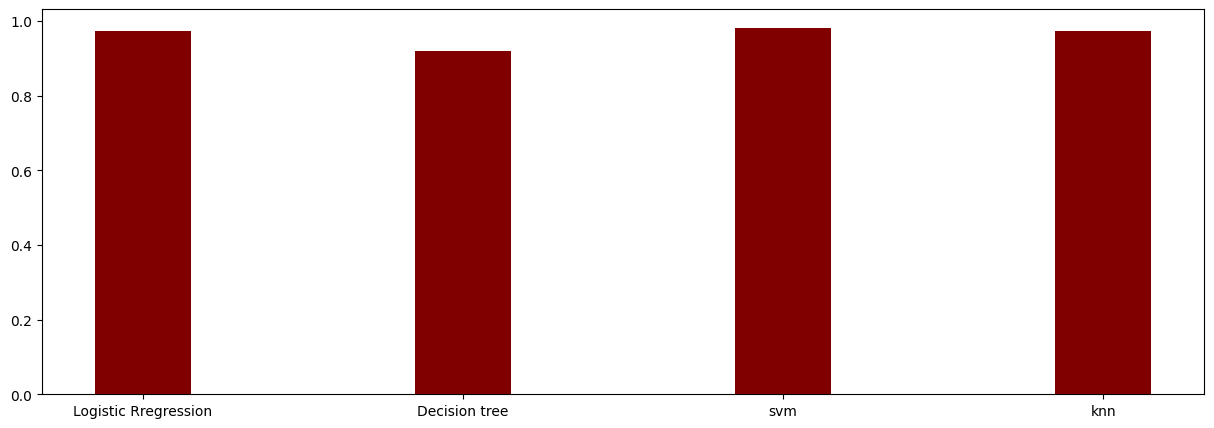

In [ ]:
fig = plt.figure(figsize = (15, 5))
print(dct)
#### BARCHART OF ACCURACY

key = list(dct.keys())
values = list(dct.values())
# creating the bar plot
plt.bar(key,values, color ='maroon',
        width = 0.3)
plt.show()

**Barchart of error**

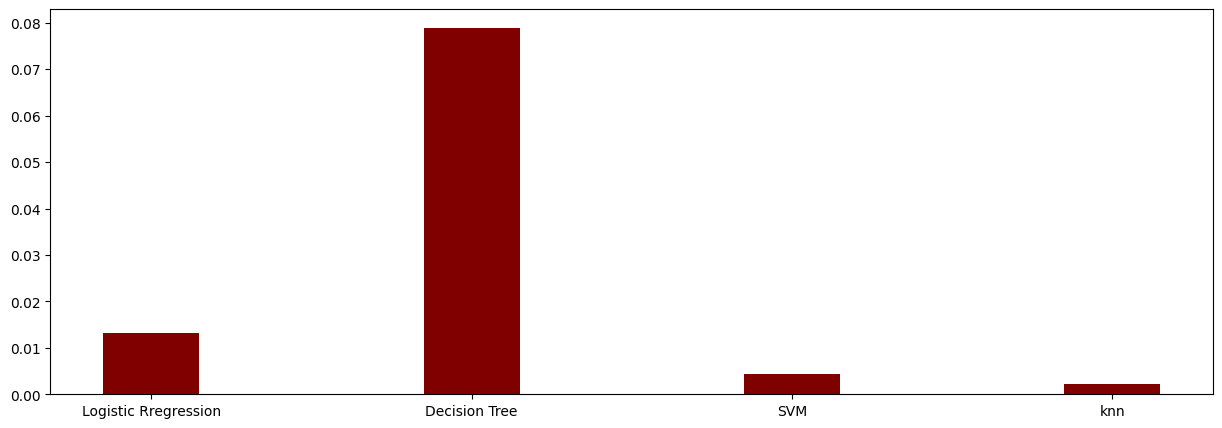

In [ ]:
fig = plt.figure(figsize = (15, 5))

#### BARCHART OF ACCURACY

key = list(dct2.keys())
values = list(dct2.values())
# creating the bar plot
plt.bar(key,values, color ='maroon',
        width = 0.3)
plt.show()

**Model Testing**

In [ ]:
import random
lst=[]
for i in range(31):
  lst.append(random.randint(0,1000))
new=tuple(lst)
print(tuple(lst)) #taking random numbers to text our model for unseen inhantances

(415, 526, 452, 545, 178, 391, 164, 272, 610, 12, 417, 269, 261, 123, 707, 613, 303, 445, 77, 703, 104, 42, 402, 45, 4, 931, 351, 318, 348, 834, 771)


In [ ]:
import numpy as np


# change the input data to a numpy array
input_data_as_numpy_array = np.asarray(new)

# reshape the numpy array as we are predicting for one datapoint
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction1 = lr.predict(input_data_reshaped) #for logistic regression model
prediction2 = dt.predict(input_data_reshaped)
prediction3 = svm.predict(input_data_reshaped)
prediction4 = knn.predict(input_data_reshaped)
print("--------------------------------------------------")
print("For logistic Regression")

if (prediction1[0] == 0):
  print('The Breast cancer is Malignant')

else:
  print('The Breast Cancer is Benign')
print("--------------------------------------------------")
print("Decision Tree:")

if (prediction2[0] == 0):
  print('The Breast cancer is Malignant')

else:
  print('The Breast Cancer is Benign')
print("--------------------------------------------------")
print("For svm:")
if (prediction3[0] == 0):
  print('The Breast cancer is Malignant')

else:
  print('The Breast Cancer is Benign')
print("--------------------------------------------------")
print("For knn:")
if (prediction4[0] == 0):
  print('The Breast cancer is Malignant')

else:
  print('The Breast Cancer is Benign')

--------------------------------------------------
For logistic Regression
The Breast Cancer is Benign
--------------------------------------------------
Decision Tree:
The Breast Cancer is Benign
--------------------------------------------------
For svm:
The Breast Cancer is Benign
--------------------------------------------------
For knn:
The Breast Cancer is Benign


In [ ]:
data.to_csv('modified.csv', index=False)